In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 05c - Causal full-information policy-router Reflection Agent

## Question and frozen decision

Can a bounded DeepSeek router add LONG and SHORT trades to immutable Union v1
without violating preregistered cost and risk limits?

**Result:** coverage increased, but the development non-inferiority gates failed;
Union v1 remains frozen. This executed reader fits nothing, makes no Cloud call
and cannot access the Q2-2026 evaluation data.

In [2]:
from pathlib import Path
from html import escape
import hashlib, json, os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

CODE_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").is_file())
os.chdir(CODE_ROOT)
CACHE = CODE_ROOT / "experiments" / "cache" / "reflection_policy_router_v4"

from experiments.reconcile_reflection_policy_router import reconcile_final_experiment
from reflection_agent.v4.config import load_v4_config
from reflection_agent.v4.contracts import RouterChoice
from reflection_agent.v4.policies import POLICY_DESCRIPTIONS, POLICY_IDS
from reflection_agent.v4.prompts import ROUTER_TASK_PROMPT, SYSTEM_PROMPT_V4, prompt_hashes

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

sealed_manifest = json.loads((CACHE / "final_report_manifest.json").read_text(encoding="utf-8"))
for name, expected in sealed_manifest.items():
    assert sha256_file(CACHE / name) == expected
stored_report = json.loads((CACHE / "final_report.json").read_text(encoding="utf-8"))
for name, expected in stored_report["table_artifacts"].items():
    assert sha256_file(CACHE / name) == expected
live_report = reconcile_final_experiment(CACHE)
assert live_report == {key: value for key, value in stored_report.items() if key != "table_artifacts"}
assert stored_report["artifact_hashes_verified"] is True
assert stored_report["union_invariant_across_variants"] is True
assert stored_report["lockbox_2026_q2_used"] is False

preflight = json.loads((CACHE / "preflight.json").read_text(encoding="utf-8"))
config = load_v4_config(CODE_ROOT / "configs" / "reflection_agent_v4.yaml")
assert preflight["passed"] is True
assert preflight["model"] == config.model
assert preflight["model_digest"] == config.required_model_digest
assert preflight["prompt_hashes"] == prompt_hashes()
assert preflight["implementation_hash"] == stored_report["implementation_hash"]

results = pd.read_parquet(CACHE / "results_table.parquet")
gates = pd.read_parquet(CACHE / "coverage_gates.parquet")
comparisons = pd.read_parquet(CACHE / "paired_comparisons.parquet")
assert results["variant"].nunique() == 14
assert stored_report["prompt_audit_passed"] == stored_report["prompt_audit_total"] == 339

stage_order = ["development", "h1", "forward"]
stage_labels = {
    "development": "Development 2021-2024",
    "h1": "H1 2025 secondary",
    "forward": "Jul-2025-Mar-2026 secondary",
}
variant_labels = {
    "static_union_only": "Union",
    "reflection_real_memory": "Real Memory",
    "reflection_no_memory": "No Memory",
    "reflection_shuffled_memory": "Shuffled Memory",
    "hedge_router": "Hedge",
    "random_router": "Seeded Random",
    "static_context_combined": "CONTEXT_COMBINED",
    "static_first_only": "FIRST_ONLY",
    "static_funding_continuation": "FUNDING_CONTINUATION",
    "static_lstm_all": "LSTM_ALL",
    "static_lstm_high": "LSTM_HIGH",
    "static_third_plus_only": "THIRD_PLUS_ONLY",
    "static_volatility_reset": "VOLATILITY_RESET",
    "static_xgb_strong": "XGB_STRONG",
}
variant_order = [
    "static_union_only", "reflection_real_memory", "reflection_no_memory",
    "reflection_shuffled_memory", "hedge_router", "random_router",
    "static_context_combined", "static_xgb_strong", "static_lstm_high",
    "static_lstm_all", "static_first_only", "static_third_plus_only",
    "static_funding_continuation", "static_volatility_reset",
]
assert set(variant_order) == set(results["variant"])

## 1. Frozen protocol and technical contract

- **Sequence:** 2021-2024 OOF development -> 2025 H1 secondary stress -> Jul-2025-Mar-2026 **secondary forward**; Q2-2026 is evaluated separately in Notebook 07.
- **Execution:** immutable LSTM DZ55 + Linear SVM DZ75 Union first; add-ons use only Union-flat, side-preserving candidates with fixed TP200/SL100, one-M15 hold, M1 stop-first replay and 5+5 bps costs.
- **Router:** one of nine host-owned policies is chosen before each UTC boundary; only fully resolved earlier policy payoffs and memory are visible.
- **Authority:** `deepseek-v4-flash:cloud` (digest `5166728b9358990e5f6c34f87cbe48716be2f2cd2d3b98527dff27ea755bf3ba`, `think=low`) returns only `choice_index` plus supplied evidence/memory indices and cannot alter trades, sides, thresholds, costs, gates or code.

In [3]:
assert sum(item["boundary_vetoes"] for item in stored_report["stage_counts"].values()) == 5
assert stored_report["forward_evidence_role"] == "secondary_reused_forward"
action_items = "".join(
    f"<li><code>{index}: {escape(policy_id)}</code> - {escape(POLICY_DESCRIPTIONS[policy_id])}</li>"
    for index, policy_id in enumerate(POLICY_IDS)
)
technical_html = f'''
<details>
<summary><b>Exact prompts, nine actions and reproducibility hashes</b></summary>
<p><b>Runtime:</b> {escape(config.model)}; digest <code>{escape(config.required_model_digest)}</code>;
<code>think={escape(config.think)}</code>; temperature 0; one bounded repair; schema <code>{RouterChoice.__name__}</code>.</p>
<p><b>Actions:</b></p><ol>{action_items}</ol>
<p><b>System prompt:</b></p><pre>{escape(SYSTEM_PROMPT_V4)}</pre>
<p><b>Router task template:</b></p><pre>{escape(ROUTER_TASK_PROMPT)}</pre>
<p><b>Prompt hashes:</b> <code>{escape(json.dumps(prompt_hashes(), sort_keys=True))}</code><br>
<b>Implementation:</b> <code>{escape(preflight['implementation_hash'])}</code><br>
<b>Protocol:</b> <code>{escape(preflight['protocol_hash'])}</code></p>
</details>
'''
display(HTML(technical_html))

## 2. Core comparison

The primary policies are immutable Union, the real-memory router, the strongest fixed context policy and guarded high-confidence XGBoost; forward checks remain descriptive.

In [4]:
core_ids = [
    "static_union_only", "reflection_real_memory",
    "static_context_combined", "static_xgb_strong",
]
union_reference = results.loc[
    results["variant"].eq("static_union_only"), ["stage", "selected_trades", "net_return"]
].rename(columns={"selected_trades": "union_trades", "net_return": "union_net"})
core = results.loc[results["variant"].isin(core_ids)].merge(union_reference, on="stage")
core["_stage"] = core["stage"].map({name: index for index, name in enumerate(stage_order)})
core["_policy"] = core["variant"].map({name: index for index, name in enumerate(core_ids)})
core = core.sort_values(["_stage", "_policy"])
core_comparison_table = pd.DataFrame({
    "Stage": core["stage"].map(stage_labels),
    "Policy": core["variant"].map(variant_labels),
    "Trades": core["selected_trades"].astype(int),
    "Growth %": (100 * (core["selected_trades"] / core["union_trades"] - 1)).round(1),
    "LONG": core["selected_long_trades"].astype(int),
    "SHORT": core["selected_short_trades"].astype(int),
    "Net %": (100 * core["net_return"]).round(2),
    "Delta net pp": (100 * (core["net_return"] - core["union_net"])).round(2),
    "Sortino": core["sortino"].round(2),
    "Checks": core["gate_count"].astype(int).astype(str) + "/10",
})
display(core_comparison_table.reset_index(drop=True))

,Stage,Policy,Trades,Growth %,LONG,SHORT,Net %,Delta net pp,Sortino,Checks
0,Development 2021-2024,Union,948,0.0,488,460,-97.69,0.00,-4.01,6/10
1,Development 2021-2024,Real Memory,1084,14.3,554,530,-110.66,-12.97,-4.35,4/10
2,Development 2021-2024,CONTEXT_COMBINED,1012,6.8,536,476,-96.36,1.33,-3.93,6/10
3,Development 2021-2024,XGB_STRONG,959,1.2,498,461,-99.95,-2.26,-4.06,4/10
4,H1 2025 secondary,Union,88,0.0,56,32,0.97,0.00,0.36,6/10
5,H1 2025 secondary,Real Memory,121,37.5,84,37,1.94,0.97,0.66,10/10
6,H1 2025 secondary,CONTEXT_COMBINED,121,37.5,84,37,1.94,0.97,0.66,10/10
7,H1 2025 secondary,XGB_STRONG,175,98.9,119,56,-12.39,-13.36,-3.07,5/10
8,Jul-2025-Mar-2026 secondary,Union,74,0.0,32,42,6.31,0.00,2.11,6/10
9,Jul-2025-Mar-2026 secondary,Real Memory,133,79.7,64,69,6.87,0.55,1.94,8/10


Takeaway: Real Memory adds trades in every period, but its development net falls by 12.97 percentage points, so Union remains frozen.

## 3. All 14 registered variants

Each cell reports the frozen selected-trade count, incremental net percentage points versus Union and, for decision stages, passed checks.

In [5]:
all_joined = results.merge(
    comparisons[["stage", "variant", "delta_net"]], on=["stage", "variant"], validate="one_to_one"
)
all_rows = []
for variant in variant_order:
    row = {"Policy": variant_labels[variant]}
    for stage, prefix in (("development", "Dev"), ("h1", "H1"), ("forward", "Forward")):
        item = all_joined.loc[
            all_joined["variant"].eq(variant) & all_joined["stage"].eq(stage)
        ].iloc[0]
        row[f"{prefix} trades"] = int(item["selected_trades"])
        row[f"{prefix} dNet pp"] = round(100 * item["delta_net"], 2)
        if stage != "forward":
            row[f"{prefix} checks"] = f"{int(item['gate_count'])}/10"
    all_rows.append(row)
all_variants_table = pd.DataFrame(all_rows)
display(all_variants_table)

,Policy,Dev trades,Dev dNet pp,Dev checks,H1 trades,H1 dNet pp,H1 checks,Forward trades,Forward dNet pp
0,Union,948,0.00,6/10,88,0.00,6/10,74,0.00
1,Real Memory,1084,-12.97,4/10,121,0.97,10/10,133,0.55
2,No Memory,948,0.00,6/10,88,0.00,6/10,74,0.00
3,Shuffled Memory,3125,-227.78,5/10,216,-11.89,5/10,536,-45.87
4,Hedge,984,-7.37,2/10,121,0.97,10/10,125,0.90
5,Seeded Random,1460,-45.66,5/10,272,-32.54,5/10,368,-14.97
6,CONTEXT_COMBINED,1012,1.33,6/10,121,0.97,10/10,125,0.90
7,XGB_STRONG,959,-2.26,4/10,175,-13.36,5/10,167,-7.90
8,LSTM_HIGH,1472,-52.76,5/10,248,-10.89,5/10,211,-14.36
9,LSTM_ALL,3454,-265.35,5/10,1022,-101.24,5/10,1001,-90.43


Takeaway: CONTEXT_COMBINED is the best fixed secondary policy, whereas XGB_STRONG adds many H1 and forward trades but makes both periods negative.

## 4. Memory controls, uncertainty and gates

The registered lexicographic objective requires both development and H1 success before Real Memory may beat no memory, shuffled policy-label memory and deterministic Hedge; paired block-bootstrap intervals are descriptive.

In [6]:
control_ids = [
    "reflection_real_memory", "reflection_no_memory",
    "reflection_shuffled_memory", "hedge_router",
]
objective_order = sorted(
    stored_report["memory_objectives"],
    key=lambda variant: tuple(stored_report["memory_objectives"][variant]),
    reverse=True,
)
objective_rank = {variant: index + 1 for index, variant in enumerate(objective_order)}

def comparison_cell(variant, stage):
    item = comparisons.loc[
        comparisons["variant"].eq(variant) & comparisons["stage"].eq(stage)
    ].iloc[0]
    return (
        int(item["delta_trades"]),
        f"{100 * item['delta_net']:+.2f} [{100 * item['delta_net_ci95_low']:+.2f}, "
        f"{100 * item['delta_net_ci95_high']:+.2f}]",
    )

control_rows = []
for variant in control_ids:
    dev_trades, dev_ci = comparison_cell(variant, "development")
    h1_trades, h1_ci = comparison_cell(variant, "h1")
    counts = stored_report["choice_counts"][variant]
    dominant_policy, dominant_blocks = max(counts.items(), key=lambda item: (item[1], item[0]))
    stage_results = results.loc[results["variant"].eq(variant)].set_index("stage")
    control_rows.append({
        "Control": variant_labels[variant],
        "Main choice": f"{dominant_policy} ({dominant_blocks}/113)",
        "Dev dTrades": dev_trades,
        "Dev dNet pp [95% CI]": dev_ci,
        "Dev checks": f"{int(stage_results.loc['development', 'gate_count'])}/10",
        "H1 dTrades": h1_trades,
        "H1 dNet pp [95% CI]": h1_ci,
        "H1 checks": f"{int(stage_results.loc['h1', 'gate_count'])}/10",
        "Objective rank": f"{objective_rank[variant]}/14",
    })
memory_controls_table = pd.DataFrame(control_rows)
display(memory_controls_table)

,Control,Main choice,Dev dTrades,Dev dNet pp [95% CI],Dev checks,H1 dTrades,H1 dNet pp [95% CI],H1 checks,Objective rank
0,Real Memory,CONTEXT_COMBINED (71/113),136,"-12.97 [-23.91, -3.92]",4/10,33,"+0.97 [-0.91, +2.93]",10/10,3/14
1,No Memory,UNION_ONLY (113/113),0,"+0.00 [+0.00, +0.00]",6/10,0,"+0.00 [+0.00, +0.00]",6/10,6/14
2,Shuffled Memory,LSTM_ALL (53/113),2177,"-227.78 [-285.58, -170.71]",5/10,128,"-11.89 [-26.40, -1.16]",5/10,9/14
3,Hedge,CONTEXT_COMBINED (70/113),36,"-7.37 [-17.76, -0.72]",2/10,33,"+0.97 [-0.92, +3.08]",10/10,5/14


Takeaway: Real Memory is the strongest memory control but passes only 4/10 development checks, so its H1 improvement cannot establish a memory benefit.

## 5. One quantity-quality graph

This figure shows the four primary policies only; the vertical and horizontal dashed lines mark the +25% trade-growth and -0.5 percentage-point net non-inferiority thresholds, while the full gate test also includes side, Sortino, drawdown, distribution and audit checks.

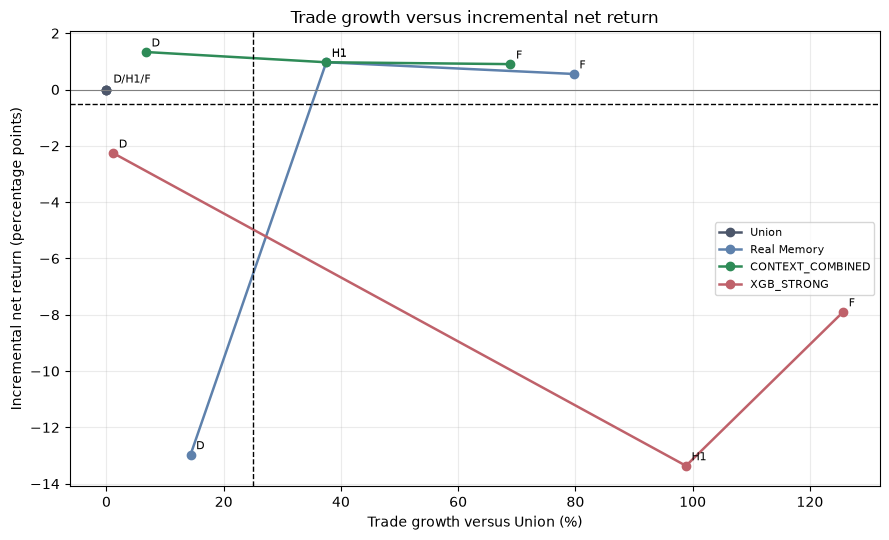

In [7]:
chart = core.copy()
chart["trade_growth_pct"] = 100 * (chart["selected_trades"] / chart["union_trades"] - 1)
chart["delta_net_pp"] = 100 * (chart["net_return"] - chart["union_net"])
stage_codes = {"development": "D", "h1": "H1", "forward": "F"}
colors = {
    "static_union_only": "#4c566a",
    "reflection_real_memory": "#5e81ac",
    "static_context_combined": "#2e8b57",
    "static_xgb_strong": "#bf616a",
}
fig, ax = plt.subplots(figsize=(9, 5.5))
for variant in core_ids:
    rows = chart.loc[chart["variant"].eq(variant)].sort_values("_stage")
    ax.plot(
        rows["trade_growth_pct"], rows["delta_net_pp"], marker="o", linewidth=1.8,
        color=colors[variant], label=variant_labels[variant],
    )
    if variant == "static_union_only":
        ax.annotate("D/H1/F", (0, 0), xytext=(5, 5), textcoords="offset points", fontsize=8)
    else:
        for _, item in rows.iterrows():
            ax.annotate(
                stage_codes[item["stage"]],
                (item["trade_growth_pct"], item["delta_net_pp"]),
                xytext=(4, 4), textcoords="offset points", fontsize=8,
            )
ax.axvline(25, color="black", linestyle="--", linewidth=1)
ax.axhline(-0.5, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Trade growth versus incremental net return")
ax.set_xlabel("Trade growth versus Union (%)")
ax.set_ylabel("Incremental net return (percentage points)")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

Takeaway: only CONTEXT_COMBINED stays above Union's net line in all three periods, but it misses the +25% development volume gate.

## 6. Reproducibility, leakage and terminal decision

The independent reconciler rehashes all artifacts, rebuilds choices and economics, checks causal memory and Union non-overlap, reproduces deterministic controls and audits every anonymous prompt.

In [8]:
assert stored_report["all_prompt_audits_passed"] is True
assert stored_report["continuous_stage_state_verified"] is True
assert stored_report["controls_called_llm"] is False
audit_table = pd.DataFrame([
    {"Check": "Cloud contract", "Evidence": f"{preflight['model']}; think={config.think}; temp=0; one repair", "Status": "VERIFIED"},
    {"Check": "Model digest", "Evidence": preflight["model_digest"][:16] + "... verified", "Status": "VERIFIED"},
    {"Check": "Implementation / protocol", "Evidence": preflight["implementation_hash"][:12] + "... / " + preflight["protocol_hash"][:12] + "...", "Status": "VERIFIED"},
    {"Check": "Registered arms / blocks", "Evidence": f"{results['variant'].nunique()} arms / {sum(x['blocks'] for x in stored_report['stage_counts'].values())} blocks", "Status": "VERIFIED"},
    {"Check": "Prompt audits", "Evidence": f"{stored_report['prompt_audit_passed']}/{stored_report['prompt_audit_total']}", "Status": "VERIFIED"},
    {"Check": "memory_benefit_established", "Evidence": str(stored_report["memory_benefit_established"]), "Status": "NOT ESTABLISHED"},
    {"Check": "Artifact hashes", "Evidence": "all registered hashes reproduced", "Status": "VERIFIED"},
    {"Check": "Union invariant / non-overlap", "Evidence": str(stored_report["union_invariant_across_variants"]), "Status": "VERIFIED"},
    {"Check": "Continuous causal memory", "Evidence": str(stored_report["continuous_stage_state_verified"]), "Status": "VERIFIED"},
    {"Check": "Deterministic controls called LLM", "Evidence": str(stored_report["controls_called_llm"]), "Status": "ZERO CALLS"},
    {"Check": "2026-Q2 used", "Evidence": str(stored_report["lockbox_2026_q2_used"]), "Status": "EXCLUDED"},
    {"Check": "Best registered objective", "Evidence": stored_report["best_variant_by_registered_objective"], "Status": "SECONDARY"},
    {"Check": "Frozen policy", "Evidence": stored_report["recommended_frozen_policy"], "Status": "FINAL"},
])
display(audit_table)

,Check,Evidence,Status
0,Cloud contract,deepseek-v4-flash:cloud; think=low; temp=0; on...,VERIFIED
1,Model digest,5166728b9358990e... verified,VERIFIED
2,Implementation / protocol,7facdb0465cd... / 875cdae00dc2...,VERIFIED
3,Registered arms / blocks,14 arms / 113 blocks,VERIFIED
4,Prompt audits,339/339,VERIFIED
5,memory_benefit_established,False,NOT ESTABLISHED
6,Artifact hashes,all registered hashes reproduced,VERIFIED
7,Union invariant / non-overlap,True,VERIFIED
8,Continuous causal memory,True,VERIFIED
9,Deterministic controls called LLM,False,ZERO CALLS


Takeaway: all 339 prompt and artifact checks pass, Q2 remains unused, and the final frozen policy is Union only.

## 7. What follows

- Stop ensemble and Reflection-policy search: 05C is the terminal controlled experiment; retain immutable Union v1.
- Report Real Memory as increased coverage without established benefit, CONTEXT_COMBINED as a positive secondary diagnostic and XGB_STRONG as rejected.
- Move to the evidence matrix and dissertation chapters, then run one separately frozen Notebook 06/Q2 lockbox evaluation only after the written protocol is final.